In [33]:
import SimpleITK as sitk

# xzy
datasets = {
    "Data1": {
        "voxel_dim": [0.707031*2, 0.707031*2, 1.25*2],
        "origin": [-181, -181, -229],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-146.5, -121.5, -96.5, -71.5, -46.5],
        "voxel_center": [0,0,-71.5]
    },
    "Data2": {
        "voxel_dim": [0.759766*2, 0.759766*2, 1.25*2],
        "origin": [-194.5, -194.5, -271],
        "positions_x": [-110],
        "positions_y": [-25, 0, 25, 50, 75],
        "positions_z": [-171.5, -146.5, -121.5, -96.5, -71.5], # exclude -171.5
        "voxel_center": [0,0,-72.25]
    },
    "Data4": {
        "voxel_dim": [0.666016*2, 0.666016*2, 1.25*2],
        "origin": [-170.5,-170.5, -188.75],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-71.5, -46.5, -21.5, 3.5],
        "voxel_center": [0,0,-32.5]
    },
    "Data5": {
        "voxel_dim": [0.689453*2, 0.689453*2, 1.25*2],
        "origin": [-176.5, -176.5, -208.25],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-96.5, -71.5, -46.5, -21.5],
        "voxel_center": [0,0,-44.5]
    },
    "Data7": {
        "voxel_dim": [0.683594*2, 0.683594*2, 1.25*2],
        "origin": [-175, -175, -199.25],
        "positions_x": [-110],
        "positions_y": [-25, 0, 25, 50, 75],
        "positions_z": [-96.5, -71.5, -46.5, -21.5],
        "voxel_center": [0,0,-29.25]
    },
    "Data8": {
        "voxel_dim": [0.726562*2, 0.726562*2, 1.25*2],
        "origin": [-186, -186, -186.25],
        "positions_x": [-110],
        "positions_y": [-25, 0, 25, 50],
        "positions_z": [-96.5, -71.5, -46.5, -21.5, 3.5],
        "voxel_center": [0,0,-16.25]
    }
}

def set_sitk_image(array, dataset):
    # Convert numpy array to SimpleITK image
    sitk_image = sitk.GetImageFromArray(array)  
    # Set the spacing for data
    spacing = datasets[dataset]["voxel_dim"]
    sitk_image.SetSpacing(spacing) #xyz
    origin = datasets[dataset]["origin"]
    sitk_image.SetOrigin(origin)
    #print(sitk_image.GetSpacing(),sitk_image.GetOrigin() )
    return sitk_image

    
def resample_image(input_image, new_spacing, new_origin):
    size = input_image.GetSize()
    spacing = input_image.GetSpacing()
    new_size = [int(size[d] * spacing[d] / new_spacing[d]) for d in range(3)]
    resampler = sitk.ResampleImageFilter()
    resampler.SetSize(new_size)
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetOutputOrigin(new_origin)
    resampler.SetOutputDirection(input_image.GetDirection())
    resampler.SetInterpolator(sitk.sitkNearestNeighbor) # preserve the original data values without smoothing
    
    resampled_image = resampler.Execute(input_image)
    return resampled_image

def extract_from_filename(filename, param):
    """Extracts energy value from the given filename."""
    parts = filename.split('_')
    if param == 'y':
        return float(parts[2][:-2])
    if param == 'z':
        return float(parts[3][:-6])
    if param == 'energy':
        return parts[1]
    else:
        return None

# function to extract ROI and convert to numpy
def extract_roi_array(image, roi_size, center_physical):
    source_index = image.TransformPhysicalPointToIndex(center_physical)
    print('source index y,z',source_index[1], source_index[2] )
    start_index = [int(source_index[0]-roi_size[0]*0.5), int(source_index[1]-roi_size[1]*0.5), int(source_index[2]-roi_size[2]*0.5)]
    print('start_index' , start_index)
    roi = sitk.RegionOfInterest(image, roi_size, start_index)
    return sitk.GetArrayFromImage(roi) 


(158, 256, 256)


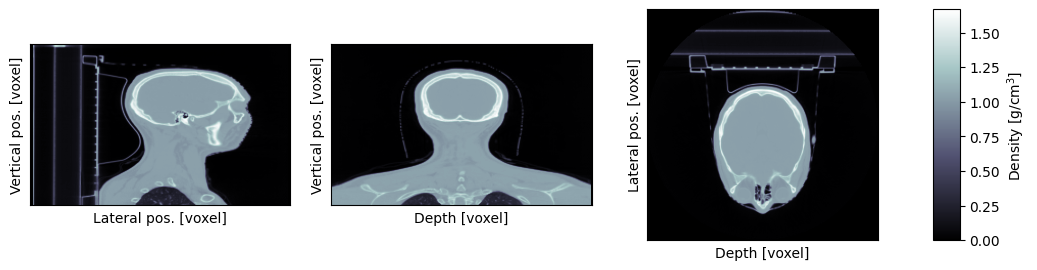

In [4]:
import numpy as np
import pandas as pd
import glob
import os
import sys
import matplotlib.pyplot as plt
import torch
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset
from torch.utils.data import DataLoader


def plot_densities_voxel(filepath, density_file):
    x_range = slice(0,256)#slice(60, 188) 
    filename = os.path.basename(filepath)
    dose = np.load(filepath)

    density = np.load(density_file)
    max_index = np.unravel_index(dose.argmax(), dose.shape)

    fig = plt.figure(figsize=(12, 3))
    gs = gridspec.GridSpec(1, 4, width_ratios=[2, 2, 2, 0.2])  # 3 plots + 1 colorbar

    # ZY plane
    ax0 = plt.subplot(gs[0])
    ax0.imshow(density[:, :, max_index[2]], cmap='gray')
    #ax0.imshow(dose[:, :,max_index[2]], cmap='inferno', alpha=0.5)
    ax0.set_xlabel('Y voxel number')
    ax0.set_ylabel('Z voxel number')


    # ZX plane
    ax1 = plt.subplot(gs[1])
    ax1.imshow(density[:, max_index[1], x_range], cmap='gray')
    #ax1.imshow(dose[:, max_index[1], x_range], cmap='inferno', alpha=0.5)
    ax1.set_xlabel('X voxel number')
    ax1.set_ylabel('Z voxel number')

    # YX plane
    ax2 = plt.subplot(gs[2])
    ax2.imshow(density[max_index[0], :, x_range], cmap='gray')
    #ax2.imshow(dose[max_index[0], :, x_range], cmap='inferno', alpha=0.5)
    ax2.set_xlabel('X voxel number')
    ax2.set_ylabel('Y voxel number')
    ax2.set_ylim(235,60)

    # Colorbar
    cax = plt.subplot(gs[3])
    cbar = plt.colorbar(ax2.get_images()[0], cax=cax)
    cbar.set_label(r'Density [g/cm$^3$]')

    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os


def plot_densities(filepath, density_file, voxel_size, origin):
    density = np.load(density_file)
    print(density.shape)
    voxel = np.arange(density.shape[2]) 
    x_vals = (voxel*voxel_size[0] -origin[0]) #- (-110) #Use depth[mm] from source as x-axis
    #'Data1':
    #voxel_size = 0.707031*2
    #x_vals = (voxel*voxel_size -181)
    zvoxel = np.arange(density.shape[0])
    z_vals = (zvoxel*voxel_size[2] -origin[2])
    # Define the mm values for the ticks within the range of x_vals
    min_x, max_x = min(x_vals), max(x_vals)
    tick_mm_values = np.arange(-150, 150, 25)  # Adjust the start and end according to your needs
    tick_mm_values = tick_mm_values[(tick_mm_values >= min_x) & (tick_mm_values <= max_x)]

    # Define the mm values for the ticks within the range of y_vals
    min_z, max_z = min(z_vals), max(z_vals)
    ztick_mm_values = np.arange(-150, 150, 25)  # Adjust the start and end according to your needs
    ztick_mm_values = ztick_mm_values[(ztick_mm_values >= min_z) & (ztick_mm_values <= max_z)]


    x_range = slice(0, 256)  # Adjust as needed
    filename = os.path.basename(filepath)
    dose = np.load(filepath)


    max_index = np.unravel_index(dose.argmax(), dose.shape)

    fig = plt.figure(figsize=(12, 3))
    gs = gridspec.GridSpec(1, 4, width_ratios=[2, 2, 2, 0.2])  # 3 plots + 1 colorbar

    # Function to convert voxel numbers to millimeters
    def voxel_to_mm(indices):
        return indices * voxel_size
    colormap = 'bone'
    # ZY plane
    ax0 = plt.subplot(gs[0])
    ax0.imshow(density[:, :, max_index[2]], cmap=colormap )
    ax0.set_xlabel('Lateral pos. [voxel]')
    ax0.set_ylabel('Vertical pos. [voxel]')


    # ZX plane
    ax1 = plt.subplot(gs[1])
    ax1.imshow(density[:, max_index[1], x_range], cmap=colormap )
    ax1.set_xlabel('Depth [voxel]')
    ax1.set_ylabel('Vertical pos. [voxel]')


    # YX plane
    ax2 = plt.subplot(gs[2])
    ax2.imshow(density[max_index[0], :, x_range], cmap=colormap )
    ax2.set_xlabel('Depth [voxel]')
    ax2.set_ylabel('Lateral pos. [voxel]')

    # Set ticks for x and z axes
    ax0.set_xticks(np.linspace(0, density.shape[2]-1, len(tick_mm_values))) # Adjust the range as needed
    ax0.set_yticks(np.linspace(0, density.shape[0]-1, len(ztick_mm_values))) # Adjust the range as needed
    ax1.set_xticks(np.linspace(0, x_range.stop - x_range.start, len(tick_mm_values))) # Adjust the range as needed
    ax1.set_yticks(np.linspace(0, density.shape[0]-1, len(ztick_mm_values))) # Adjust the range as needed
    ax2.set_xticks(np.linspace(0, x_range.stop - x_range.start, len(tick_mm_values))) # Adjust the range as needed
    ax2.set_yticks(np.linspace(0, density.shape[1]-1, len(tick_mm_values))) # Adjust the range as needed

    # Now set the tick labels
    ax0.set_xticklabels(tick_mm_values)
    ax0.set_yticklabels(ztick_mm_values)
    ax1.set_xticklabels(tick_mm_values)
    ax1.set_yticklabels(ztick_mm_values)
    ax2.set_xticklabels(tick_mm_values)
    ax2.set_yticklabels(tick_mm_values)



    # Colorbar
    cax = plt.subplot(gs[3])
    cbar = plt.colorbar(ax2.get_images()[0], cax=cax)
    cbar.set_label(r'Density [g/cm$^3$]')


    plt.show()

density2_file = "/scratch/tappay01/densities/Data2.npy"
plot_densities("/scratch/tappay01/new_data/Ali/Data2_1250MeV_-25Mm_-121.5Mm.npy",
                density2_file,
               datasets["Data2"]["voxel_dim"],
               datasets["Data2"]["origin"]
               )

In [5]:

DATASET_NAME = 'Dataset'

NUMBER_OF_SLICES = 126

VOXELNUMBER_X = 256

VOXELNUMBER_Y = 256

DELTA_Z = 1.25*2

DELTA_X = 0.707031*2

DELTA_Y = 0.707031*2

#

X_MIN = -181

Y_MIN = -181

Z_MIN = -229

In [44]:
def plot_source(density_path , Data):
    density = np.load(density_path)
    print("density.shape ",density.shape) # zyx (124, 256, 256) 

    voxel_size = datasets[Data]["voxel_dim"] # Example voxel sizes in mm for each dimension
    origin = datasets[Data]["origin"]  # Example origin in mm for each dimension

    # Coordinates for the red points
    lateral_positions = datasets[Data]["positions_y"] #[-50, -25, 0, 25, 50, 75]
    vertical_positions = datasets[Data]["positions_z"] #[-71.5, -46.5, -21.5, 3.5]

    # Calculate the x and z values in millimeters
    voxel = np.arange(density.shape[2]+1) 
    x_vals = (voxel * voxel_size[0] + origin[0])
    yvoxel = np.arange(density.shape[1]+1)
    y_vals = (yvoxel * voxel_size[1] + origin[1])
    zvoxel = np.arange(density.shape[0]+1)
    z_vals = (zvoxel * voxel_size[2] + origin[2])
    print("y_vals ",min(y_vals), max(y_vals))
    print("z_vals ",min(z_vals), max(z_vals))
    x_extent = [-origin[0], origin[0]] #-X_MIN,X_MIN
    y_extent = [origin[1], -origin[1]] #Y_MIN,-Y_MIN
    z_extent = [ max(z_vals) ,min(z_vals)] #86,Z_MIN
    # Define the mm values for the ticks within the range of x_vals and z_vals
    tick_mm_values = np.arange(np.floor(min(x_vals)), np.ceil(max(x_vals)) + 1, 25)  # in mm
    ytick_mm_values = np.arange(np.floor(min(y_vals)), np.ceil(max(y_vals)) + 1, 25)  # in mm
    ztick_mm_values = np.arange(np.floor(min(z_vals)), np.ceil(max(z_vals)) + 1, 25)  # in mm

    # Define the mm values for the ticks within the range of x_vals
    min_x, max_x = min(x_vals), max(x_vals)
    tick_mm_values = np.arange(-150, 175, 50)  # Adjust the start and end according to your needs
    tick_mm_values = tick_mm_values[(tick_mm_values >= min_x) & (tick_mm_values <= max_x)]

    min_y, max_y = min(y_vals), max(y_vals)
    ytick_mm_values = np.arange(-200, 200, 50)  # Adjust the start and end according to your needs
    ytick_mm_values = ytick_mm_values[(ytick_mm_values >= min_y) & (ytick_mm_values <= max_y)]

    min_z, max_z = min(z_vals), max(z_vals)
    ztick_mm_values = np.arange(-250, 150, 50)  # Adjust the start and end according to your needs
    ztick_mm_values = ztick_mm_values[(ztick_mm_values >= min_z) & (ztick_mm_values <= max_z)]



    # Identify the slice with the maximum density value
    max_index = [50,128,120]


    # Create figure and grid specification
    fig = plt.figure(figsize=(15, 3))
    gs = gridspec.GridSpec(1, 4, width_ratios=[2, 2, 2, 0.2])  # 3 plots + 1 colorbar

    colormap = 'bone'
    # ZY plane
    ax0 = plt.subplot(gs[0])
    zy_slice = density[:, :, max_index[2]]
    cax0 = ax0.imshow(zy_slice, cmap=colormap, extent=y_extent + z_extent)
    ax0.set_xlabel('Lateral pos. [mm]')
    ax0.set_ylabel('Vertical pos. [mm]')
    ax0.set_xticks(ytick_mm_values)
    ax0.set_yticks(ztick_mm_values)
    ax0.set_xticklabels(ytick_mm_values.astype(int))
    ax0.set_yticklabels(ztick_mm_values.astype(int))


    # Add red points to the ZY plane plot
    for y in lateral_positions:
        for z in vertical_positions:
            ax0.scatter(y, z, color='red', s=5)  # s is the size of the point
        
    # ZX plane
    ax1 = plt.subplot(gs[1])
    zx_slice = density[:, max_index[1], :]
    cax1 = ax1.imshow(zx_slice, cmap=colormap,extent=[origin[0], -origin[0],max(z_vals) ,min(z_vals)] )
    ax1.set_xlabel('Depth [mm]')
    ax1.set_ylabel('Vertical pos. [mm]')
    ax1.set_xticks(tick_mm_values)
    ax1.set_yticks(ztick_mm_values)
    ax1.set_xticklabels([f"{mm:.0f}" for mm in tick_mm_values])
    ax1.set_yticklabels(ztick_mm_values.astype(int))
    # Add horizontal lines at specified vertical positions
    for vert in vertical_positions:
        ax1.scatter(-110, vert, s=30, facecolors='none', edgecolors = 'firebrick', label = 'source')
        ax1.axhline(vert,  xmin=0.2, xmax=0.8, color = 'red', linestyle = '--', label = 'beam',alpha=0.8, linewidth=1.5) 

    # YX plane
    ax2 = plt.subplot(gs[2])
    yx_slice = density[max_index[0], :, :]
    cax2 = ax2.imshow(yx_slice, cmap=colormap, extent=[ origin[0], -origin[0], -origin[1], origin[1]] )
    ax2.set_xlabel('Depth [mm]')
    ax2.set_ylabel('Lateral pos. [mm]')
    ax2.set_xticks(tick_mm_values)
    ax2.set_yticks(ytick_mm_values)  # Assuming lateral pos. uses the same scale
    ax2.set_xticklabels(tick_mm_values.astype(int))
    ax2.set_yticklabels(ytick_mm_values.astype(int))
    # Add horizontal lines at specified vertical positions
    for lat in lateral_positions:
        ax2.scatter(-110, lat, s=30, facecolors='none', edgecolors = 'firebrick', label = 'source')
        ax2.axhline(y=lat,xmin=0.2, xmax=0.8, color = 'red', linestyle = '--', label = 'beam',alpha=0.8, linewidth=1.5)

    # Colorbar
    #cax = plt.subplot(gs[3])
    cbar_ax = fig.add_axes([0.85, 0.1, 0.01, 0.7]) # Adjust the third value for width

    # Create colorbar in the custom axes
    cbar = plt.colorbar(cax2, cax=cbar_ax)
    cbar.set_label(r'Density [g/cm$^3$]')
    plt.title(str(Data))
    plt.show()


density.shape  (126, 256, 256)
y_vals  -181.0 180.99987199999998
z_vals  -229.0 86.0


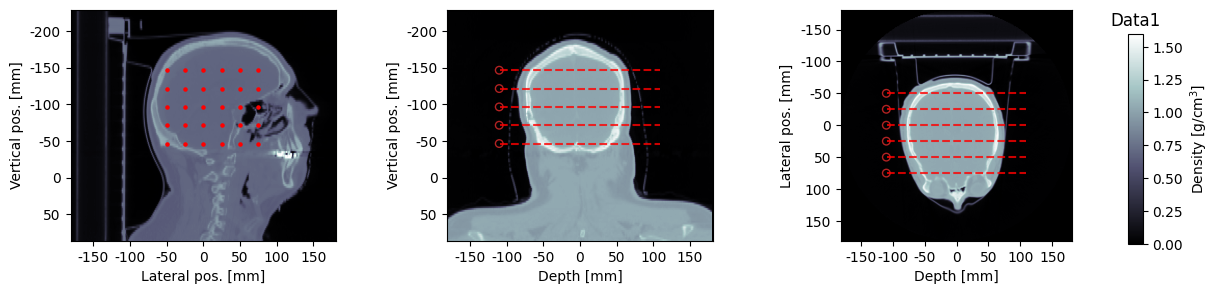

In [31]:
Data = "Data1"
density_path = "/gpfs001/scratch/schwar14/simudosemapheavyions/DosemapInBrain/Dataset/densities.npy"#"/scratch/tappay01/densities/Data4.npy"

plot_source(density_path , Data)

density.shape  (158, 256, 256)
y_vals  -194.5 194.50019200000003
z_vals  -271.0 124.0


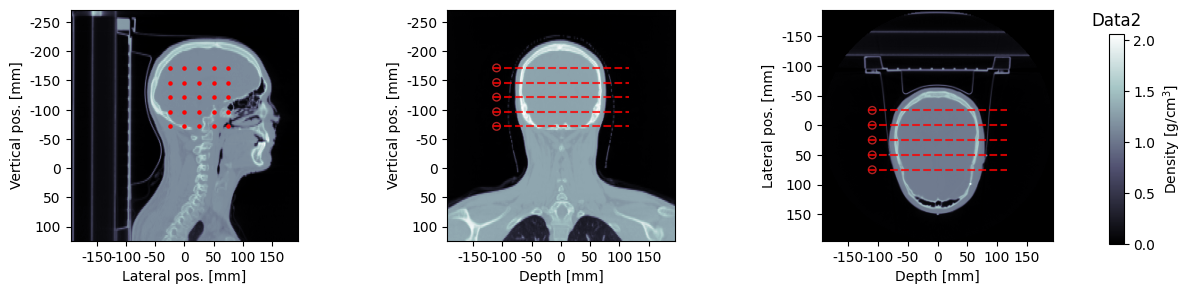

In [48]:
# Load the density data from the file provided

Data = "Data2"
density_path = "/gpfs001/scratch/schwar14/simudosemapheavyions/DosemapInBrain/Dataset2/densities.npy"#"/scratch/tappay01/densities/Data4.npy"

plot_source(density_path , Data)


density.shape  (124, 256, 256)
y_vals  -170.5 170.50019200000003
z_vals  -188.75 121.25


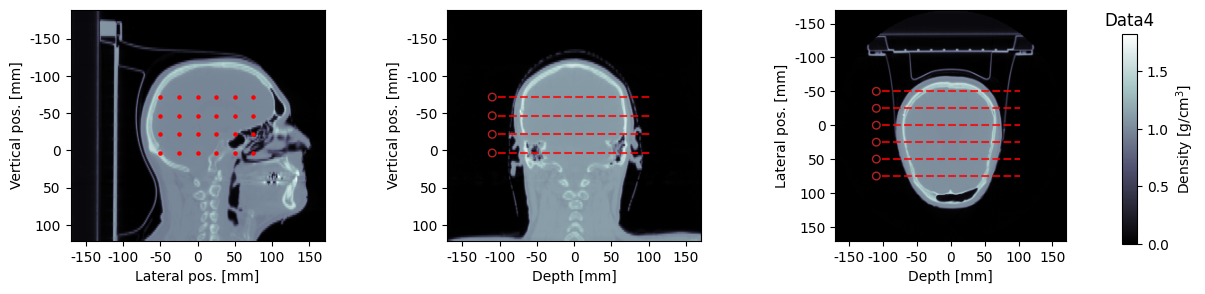

In [47]:
# Load the density data from the file provided
Data = "Data4"
density_path = "/gpfs001/scratch/schwar14/simudosemapheavyions/DosemapInBrain/Dataset4/densities.npy"#"/scratch/tappay01/densities/Data4.npy"

plot_source(density_path , Data)

density.shape  (130, 256, 256)
y_vals  -176.5 176.499936
z_vals  -208.25 116.75


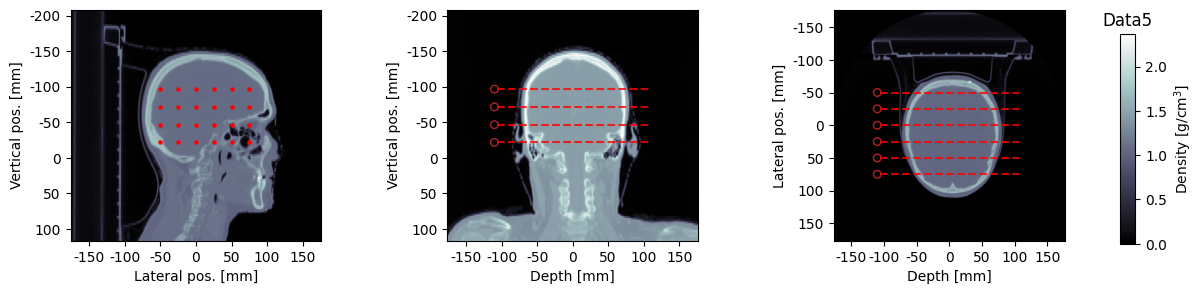

In [46]:

Data = "Data5"
density_path = "/gpfs001/scratch/schwar14/simudosemapheavyions/DosemapInBrain/Dataset5/densities.npy"
plot_source(density_path , Data)

density.shape  (135, 256, 256)
y_vals  -175.0 175.00012800000002
z_vals  -199.25 138.25


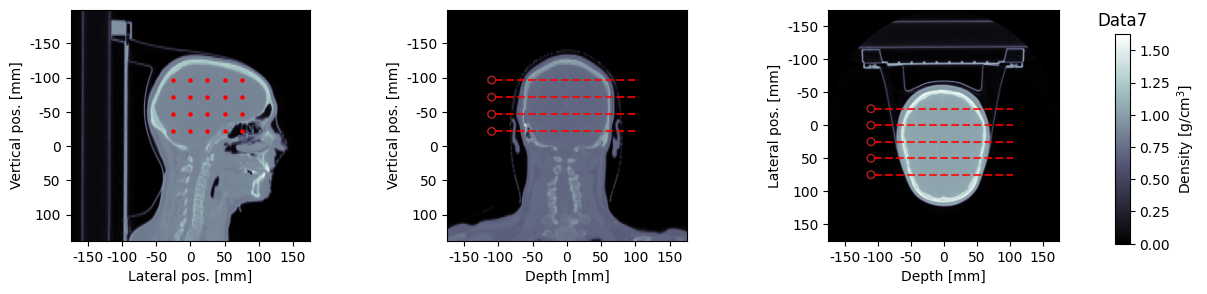

In [45]:
Data = "Data7"
density_path = "/gpfs001/scratch/schwar14/simudosemapheavyions/DosemapInBrain/Dataset7/densities.npy"
plot_source(density_path , Data)

density.shape  (135, 256, 256)
y_vals  -186.0 185.99974400000002
z_vals  -186.25 151.25


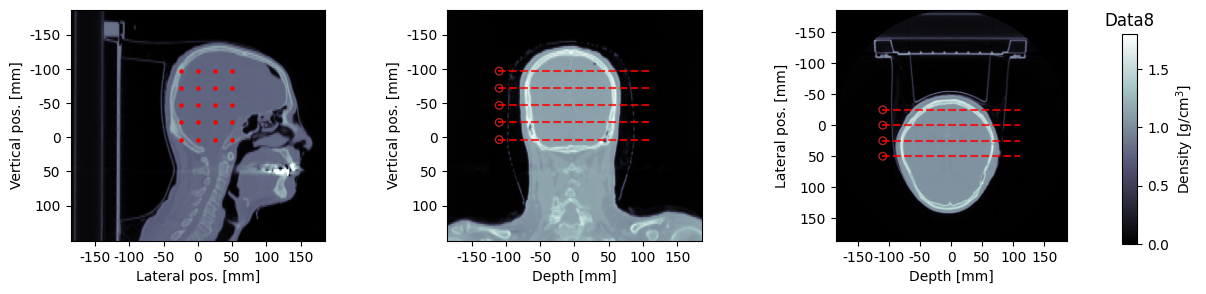

In [49]:
Data = "Data8"
density_path = "/gpfs001/scratch/schwar14/simudosemapheavyions/DosemapInBrain/Dataset8/densities.npy"
plot_source(density_path , Data)

In [3]:
import torch
import matplotlib.pyplot as plt
from matplotlib import gridspec
def plot_roi(roi_array,density):

    # Define center of the volume
    i =  int(roi_array.shape[0]/2)-1

    data_sample = roi_array

    print('Y direction')
    print('voxel number ',i)
    #density_sample = density_batch[i, 0]
    #data_name_sample = data_name_batch[i]
    # Define the figure and the grid
    fig = plt.figure(figsize=(15, 3))
    gs = gridspec.GridSpec(1, 3, width_ratios=[1, 2, 0.2])  # 3 plots + 1 colorbar
    max_index = np.unravel_index(data_sample.argmax(), data_sample.shape)
        
    # ZY plane
    ax0 = plt.subplot(gs[0])
    ax0.imshow(density[:, :, max_index[2]], cmap='gray')
    ax0.imshow(data_sample[:, :,max_index[2]], cmap='inferno', alpha=0.7)
    ax0.set_title("ZY Plane")
    ax0.set_xlabel('Z voxel number')
    ax0.set_ylabel('Y voxel number')

    # ZX plane
    ax1 = plt.subplot(gs[1])
    ax1.imshow(density[:, i, :], cmap='gray')
    img_data = ax1.imshow(data_sample[:, i, :], cmap='inferno', alpha=0.7)
    ax1.set_xlabel('X voxel number')
    ax1.set_ylabel('Z voxel number')

    # Colorbar
    cax = plt.subplot(gs[2])
    cbar = plt.colorbar(img_data, cax=cax)
    cbar.set_label('Dose [Gy')

    plt.tight_layout()
    plt.show()

    print('Z direction')

    print('voxel number ',i)
    #density_sample = density_batch[i, 0]
    #data_name_sample = data_name_batch[i]
    # Define the figure and the grid
    fig = plt.figure(figsize=(15, 3))
    gs = gridspec.GridSpec(1, 3, width_ratios=[1, 2, 0.2])  # 3 plots + 1 colorbar
    max_index = np.unravel_index(data_sample.argmax(), data_sample.shape)
        
    # ZY plane
    ax0 = plt.subplot(gs[0])
    ax0.imshow(density[:, :, max_index[2]], cmap='gray')
    ax0.imshow(data_sample[:, :,max_index[2]], cmap='inferno', alpha=0.7)
    ax0.set_title("ZY Plane")
    ax0.set_xlabel('Z voxel number')
    ax0.set_ylabel('Y voxel number')

    # YX plane
    ax2 = plt.subplot(gs[1])
    ax2.imshow(density[i, :, :], cmap='gray')
    img_data = ax2.imshow(data_sample[i, :, :], cmap='inferno', alpha=0.7)
    ax2.set_xlabel('X voxel number')
    ax2.set_ylabel('Y voxel number')

    # Colorbar
    cax = plt.subplot(gs[2])
    cbar = plt.colorbar(img_data, cax=cax)
    cbar.set_label('Dose [Gy]')

    plt.tight_layout()
    plt.show()

In [4]:
def resample_density(density_path, target_dataset):
    '''Take input as density file path and convert to SimpleITK image and resample to physical space of Data1
return resampled SimpleITK image'''

    filename = os.path.basename(density_path) # Example "Data2.npy"
    dataset = filename.split('.')[0]    #Data2
    target_spacing = datasets[target_dataset]["voxel_dim"]
    target_origin = datasets[target_dataset]["origin"]
    
    #print(dataset)
    # Load data from .npy
    array = np.load(density_path)
    #print(array.shape)
    # Convert numpy array to SimpleITK image and set parameters
    image = set_sitk_image(array, dataset)

    if dataset != target_dataset:
        # Resample the image
        resampled = resample_image(image, target_spacing, target_origin)
    if dataset == target_dataset:
        resampled = image
    return resampled

def get_density_roi(filepath):
    roi_size = (256,16,16) #xyz  
    filename = os.path.basename(filepath) # Example "Data1_1500MeV_0Mm_-121.5Mm.npy"
    dataset = filename.split('_')[0] # Example Data1, Data2
    density_folder =  "/scratch/tappay01/densities/"
    density_path = os.path.join(density_folder,  dataset +'.npy')
    resampled = resample_density(density_path, 'Data4')
    # Extract ROI    
    # y z source position extract from file name
    source_physical = [0, extract_from_filename(filename,'y'), extract_from_filename(filename,'z')]
    density_roi_array = extract_roi_array(resampled, roi_size, source_physical)

    return density_roi_array

In [5]:
datasets["Data2"]["origin"]

[-194.5, -194.5, -271]

(158, 256, 256)


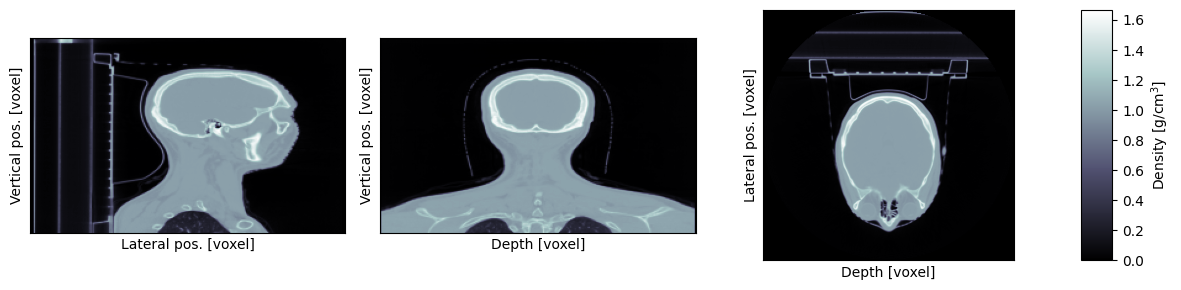

In [5]:
density2_file = "/scratch/tappay01/densities/Data2.npy"
plot_densities("/scratch/tappay01/new_data/Ali/Data2_1250MeV_-25Mm_-121.5Mm.npy",
                density2_file,
               datasets["Data2"]["voxel_dim"],
               datasets["Data2"]["origin"]
               )

Check some file of resampled data and plot with its density.


array shape (16, 16, 128)
source index y,z 128 33
start_index [60, 120, 25]
Y direction
voxel number  7


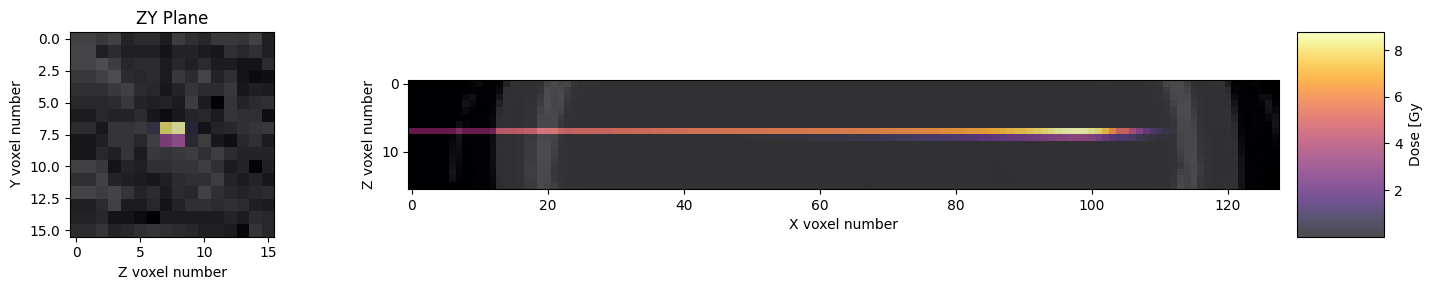

Z direction
voxel number  7


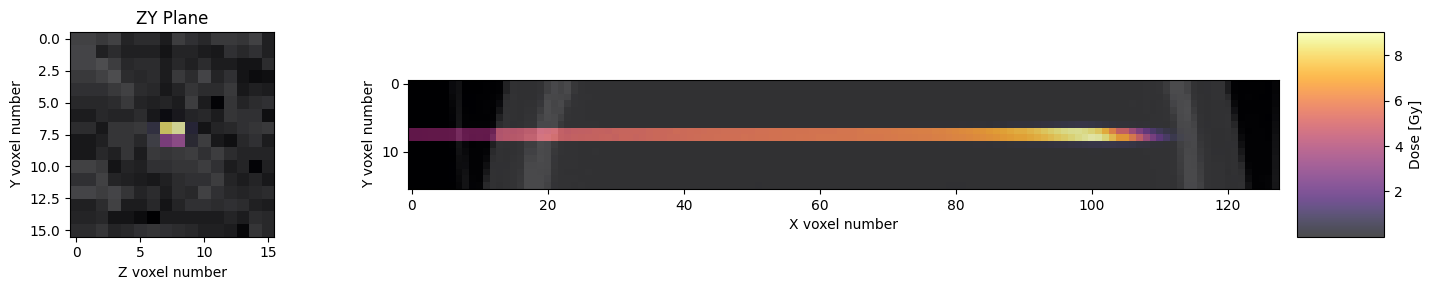

In [6]:
roi_array2 = np.load("/scratch/tappay01/data/data2_resampled/Data2_1500MeV_0Mm_-146.5Mm.npy")
print('array shape', roi_array2.shape)
density2_roi_array = get_density_roi(file_data2)
plot_roi(roi_array2, density2_roi_array)

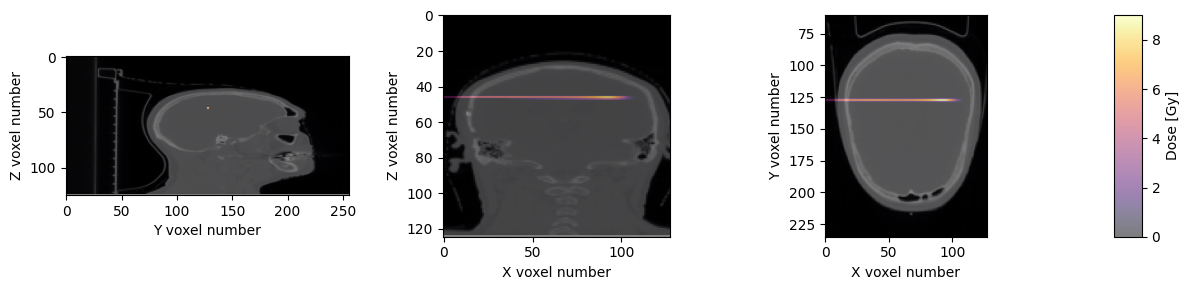

In [7]:
density4_file = "/scratch/tappay01/densities/Data4.npy"
file_data4 ="/scratch/tappay01/data/data4/Data4_1500MeV_0Mm_-71.5Mm.npy"
plot_densities(file_data4, density4_file)

array shape (16, 16, 128)
source index y,z 128 63
start_index [60, 120, 55]
Y direction
voxel number  7


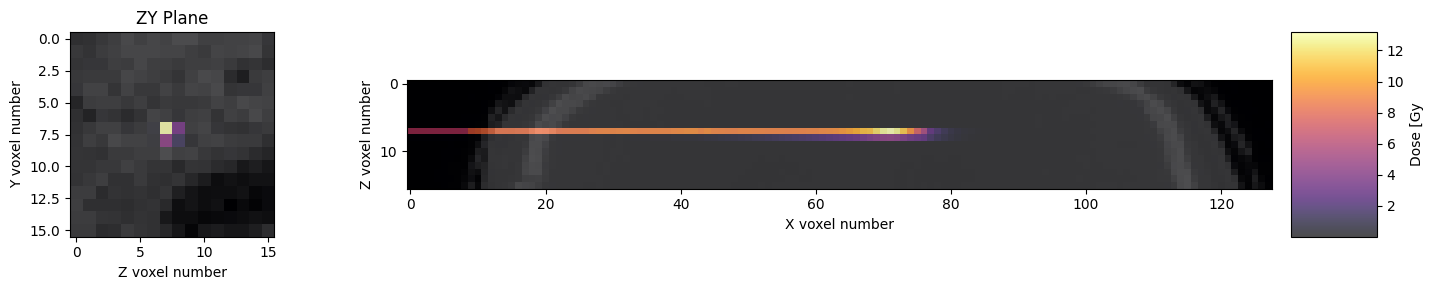

Z direction
voxel number  7


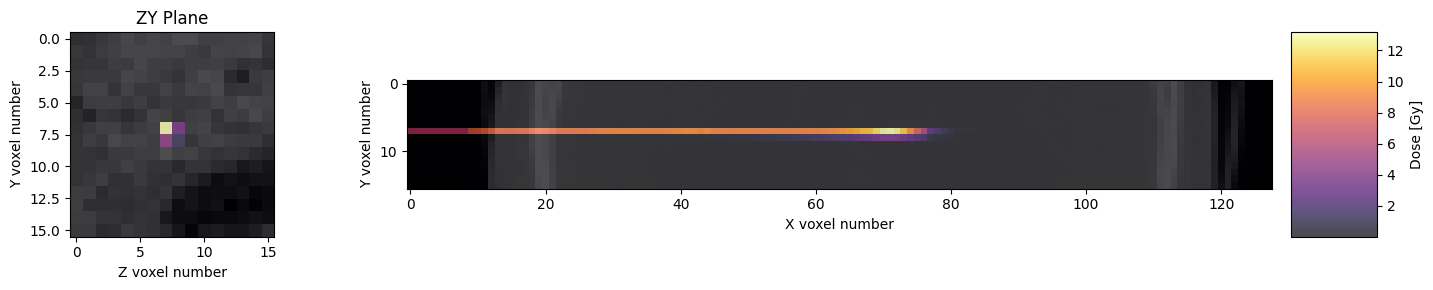

In [8]:
roi_array = np.load("/scratch/tappay01/data/data4_resampled/Data4_2000MeV_25Mm_3.5Mm.npy")
print('array shape', roi_array.shape)
density_roi_array = get_density_roi(file_data4)
plot_roi(roi_array, density_roi_array)

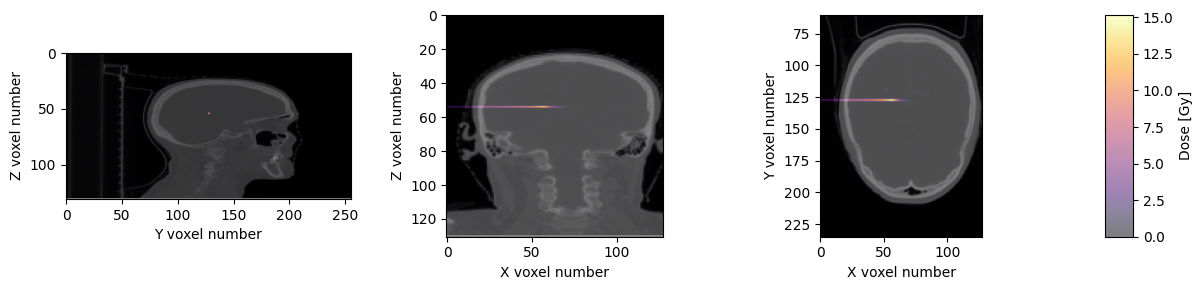

In [9]:
density5_file = "/scratch/tappay01/densities/Data5.npy"
file_data5 = "/scratch/tappay01/data/data5/Data5_1250MeV_0Mm_-71.5Mm.npy"
plot_densities(file_data5, density5_file)

array shape (16, 16, 128)
source index y,z 128 63
start_index [60, 120, 55]
Y direction
voxel number  7


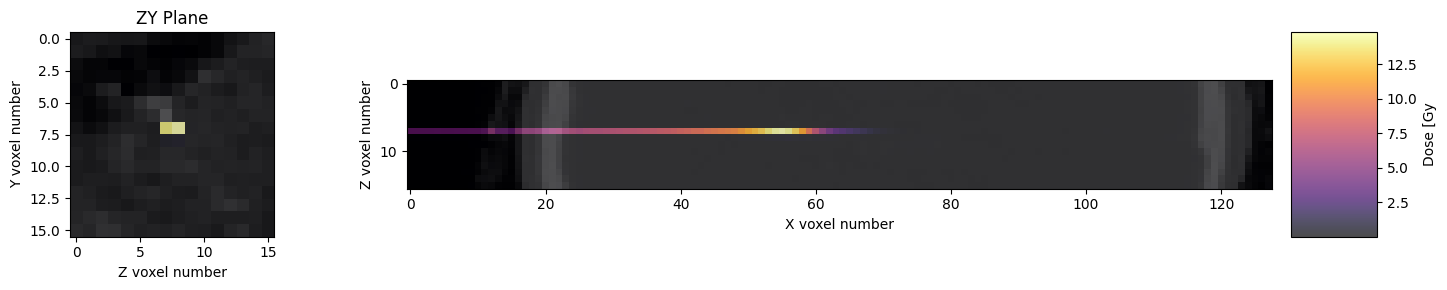

Z direction
voxel number  7


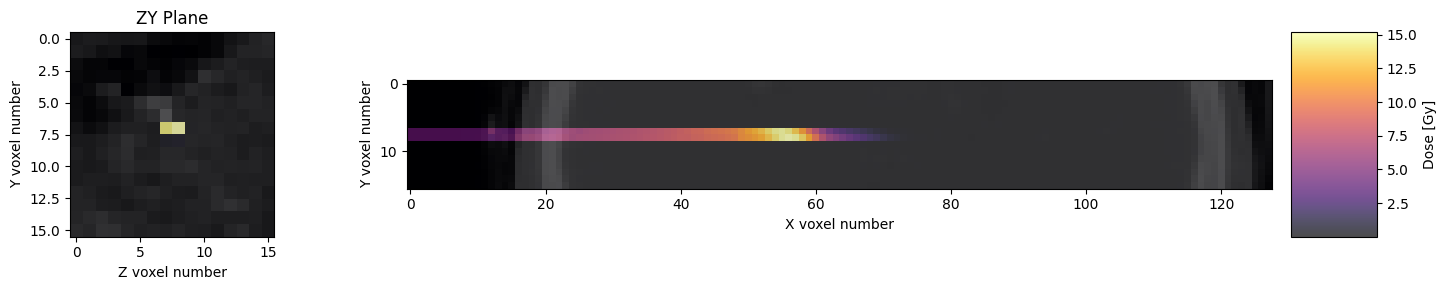

In [10]:
roi_array = np.load("/scratch/tappay01/data/data5_resampled/Data5_1250MeV_0Mm_-71.5Mm.npy")
print('array shape', roi_array.shape)
density_roi_array = get_density_roi(file_data5)
plot_roi(roi_array, density_roi_array)

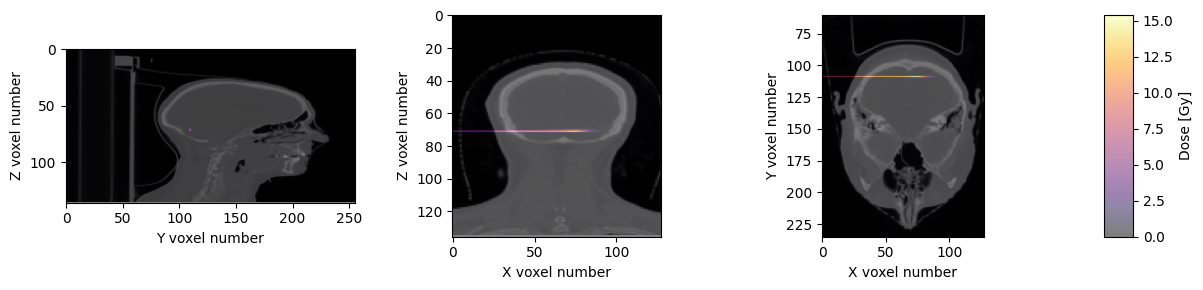

In [11]:
density7_file = "/scratch/tappay01/densities/Data7.npy"
file_data7 = "/scratch/tappay01/data/data7/Data7_1500MeV_-25Mm_-21.5Mm.npy"
plot_densities(file_data7, density7_file)

array shape (16, 16, 128)
source index y,z 110 83
start_index [60, 102, 75]
Y direction
voxel number  7


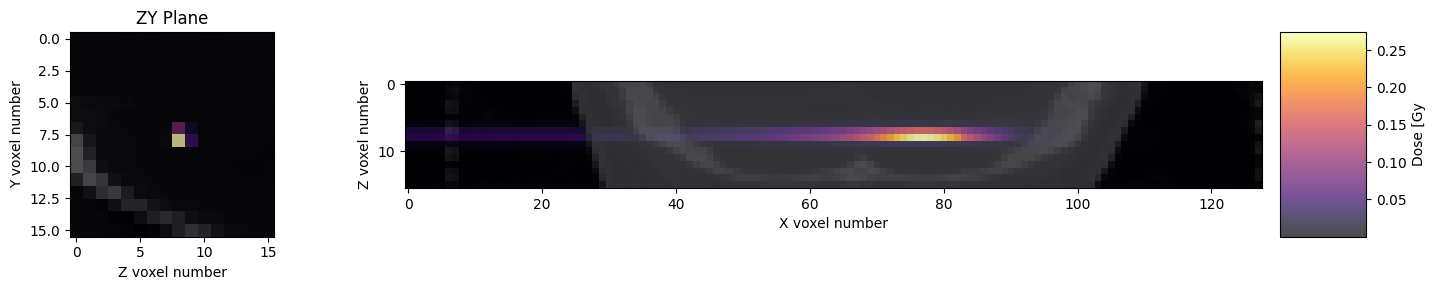

Z direction
voxel number  7


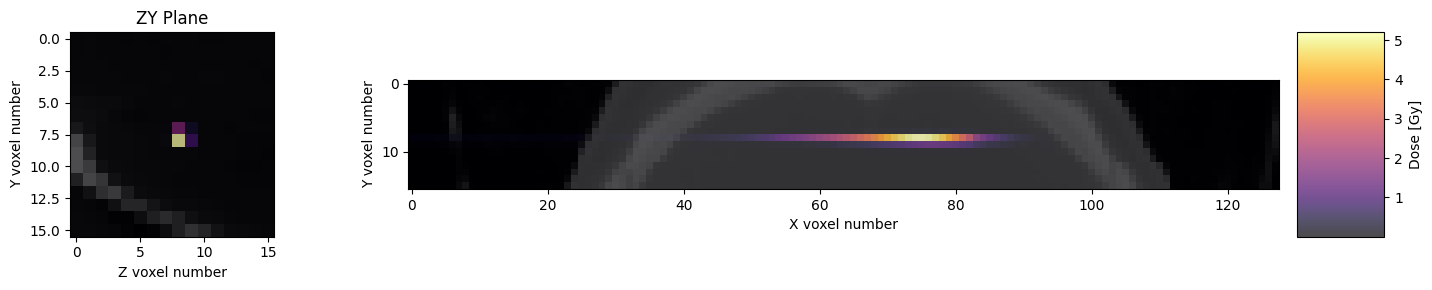

In [12]:
roi_array = np.load("/scratch/tappay01/data/data7_resampled/Data7_1500MeV_-25Mm_-21.5Mm.npy")
print('array shape', roi_array.shape)
density_roi_array = get_density_roi(file_data7)
plot_roi(roi_array, density_roi_array)

Resample all denstities.npy to same voxel size and shape as target size. Save to new .npy file. Cropping to ROI will be done with CustomDataset. ==> Data4 5 7 are smaller and will get error when resampled to Data1.

The way to do is to crop it to ROI of 16x16x128 just like above for all 30 positions and save them as .npy. CustomDataset will find the corresponding filename.

In [4]:
def create_density_roi(dataset, target_dataset):
    roi_size = (256,16,16) #xyz  
    density_folder =  "/scratch/tappay01/densities/"
    original_density_path = os.path.join(density_folder,  dataset +'.npy')
    resampled = resample_density(original_density_path, target_dataset)
    # Extract ROI    
    # y z source position extract from Dataset notes
    # source at x postion = -110
    # full X range size 256
    for y in datasets[dataset]["positions_y"]:
        for z in datasets[dataset]["positions_z"]:
            source_physical = [0, y, z] #Mm
            print('source_physical: ',source_physical)
            density_roi_array = extract_roi_array(resampled, roi_size, source_physical)
            np.save(os.path.join('/scratch/tappay01/densities_to_dataset4/','{}_{}Mm_{}Mm.npy'.format(dataset, y, z)), density_roi_array)


create_density_roi('Data8', 'Data4')

source_physical:  [0, -25, -96.5]
source index y,z 109 37
start_index [0, 101, 29]
source_physical:  [0, -25, -71.5]
source index y,z 109 47
start_index [0, 101, 39]
source_physical:  [0, -25, -46.5]
source index y,z 109 57
start_index [0, 101, 49]
source_physical:  [0, -25, -21.5]
source index y,z 109 67
start_index [0, 101, 59]
source_physical:  [0, -25, 3.5]
source index y,z 109 77
start_index [0, 101, 69]
source_physical:  [0, 0, -96.5]
source index y,z 128 37
start_index [0, 120, 29]
source_physical:  [0, 0, -71.5]
source index y,z 128 47
start_index [0, 120, 39]
source_physical:  [0, 0, -46.5]
source index y,z 128 57
start_index [0, 120, 49]
source_physical:  [0, 0, -21.5]
source index y,z 128 67
start_index [0, 120, 59]
source_physical:  [0, 0, 3.5]
source index y,z 128 77
start_index [0, 120, 69]
source_physical:  [0, 25, -96.5]
source index y,z 147 37
start_index [0, 139, 29]
source_physical:  [0, 25, -71.5]
source index y,z 147 47
start_index [0, 139, 39]
source_physical:  [0

Check that we have the same density part as above when loading from file.

array shape (16, 16, 128)
Y direction
voxel number  7


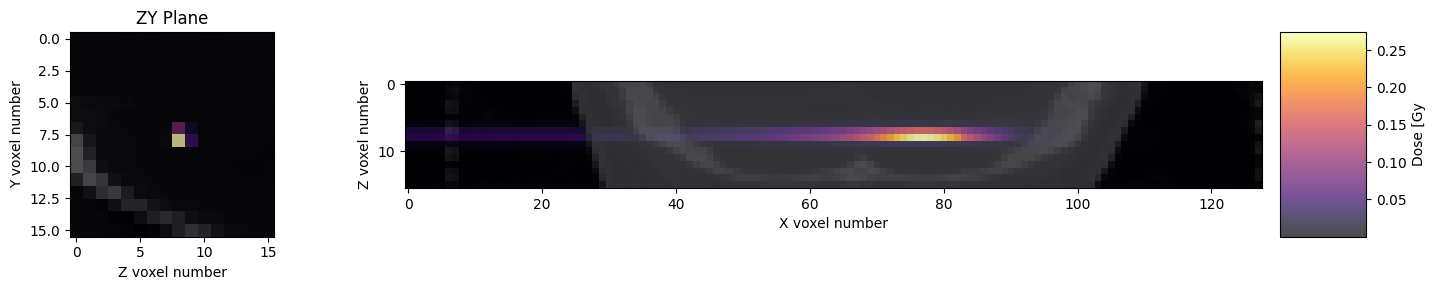

Z direction
voxel number  7


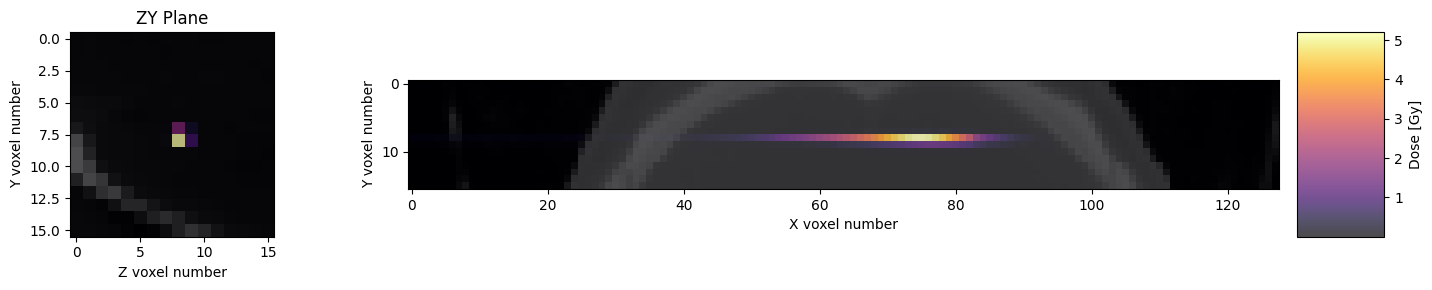

In [17]:
roi_array = np.load("/scratch/tappay01/data/data7_resampled/Data7_1500MeV_-25Mm_-21.5Mm.npy")
print('array shape', roi_array.shape)
density_roi_array_from_file = np.load("/scratch/tappay01/densities/Data7_-25Mm_-21.5Mm.npy")
plot_roi(roi_array, density_roi_array_from_file)